In [ ]:
#Espacio para cargar módulos necesarios para el programa.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV


In [ ]:
print("--- 1. CARGA DEL DATASET ---")
df = pd.read_csv(r"C:\Users\jorge\Documents\Nuclio - Data Scientist & Ia\Entregable 2\sample_mmp.csv", low_memory=False)

--- 1. CARGA DEL DATASET ---


In [5]:
print(f"Número total de máquinas: {df.shape[0]}")
print(f"Número total de variables iniciales: {df.shape[1]}")

# Eliminamos MachineIdentifier porque, según el diccionario, es solo el ID de la máquina
if 'MachineIdentifier' in df.columns:
    df.drop('MachineIdentifier', axis=1, inplace=True)
    print("✅ Columna 'MachineIdentifier' eliminada (no predictiva).")

print(f"\nVariables restantes para analizar: {df.shape[1]}")

Número total de máquinas: 500000
Número total de variables iniciales: 84
✅ Columna 'MachineIdentifier' eliminada (no predictiva).

Variables restantes para analizar: 83


In [6]:
print("--- 2. ANÁLISIS DE NULOS BASADO EN CONTEXTO ---")

def analizar_nulos_contexto(dataframe):
    """Calcula el % de nulos y devuelve un DataFrame ordenado."""
    nulos = dataframe.isnull().sum()
    porcentaje = (nulos / len(dataframe)) * 100
    df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})
    return df_nulos[df_nulos['Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

nulos_info = analizar_nulos_contexto(df)

print("\n--- COLUMNAS CON MÁS DE UN 30% DE NULOS ---")
# Filtramos para ver los casos más críticos
display(nulos_info[nulos_info['Porcentaje (%)'] > 30.0])

--- 2. ANÁLISIS DE NULOS BASADO EN CONTEXTO ---

--- COLUMNAS CON MÁS DE UN 30% DE NULOS ---


,Nulos,Porcentaje (%)
PuaMode,499874,99.9748
Census_ProcessorClass,497918,99.5836
DefaultBrowsersIdentifier,475939,95.1878
Census_IsFlightingInternal,415225,83.0450
Census_InternalBatteryType,355603,71.1206
Census_ThresholdOptIn,318104,63.6208
Census_IsWIMBootEnabled,317666,63.5332
SmartScreen,178596,35.7192
OrganizationIdentifier,154563,30.9126


In [7]:
print("--- 3. LIMPIEZA E IMPUTACIÓN INTELIGENTE ---")

# 1. Eliminamos las columnas irrecuperables u obsoletas
columnas_a_borrar = [
    'PuaMode', 'Census_ProcessorClass', 'DefaultBrowsersIdentifier', 
    'Census_IsFlightingInternal', 'Census_InternalBatteryType', 
    'Census_ThresholdOptIn', 'Census_IsWIMBootEnabled'
]
df.drop(columns=columnas_a_borrar, inplace=True, errors='ignore')
print(f"✅ Se han eliminado {len(columnas_a_borrar)} columnas basándonos en el diccionario de datos.")

# 2. Imputación inteligente de las variables clave que salvamos
if 'SmartScreen' in df.columns:
    df['SmartScreen'] = df['SmartScreen'].fillna('ExistsNotSet')
    print("✅ 'SmartScreen': Nulos imputados como 'ExistsNotSet'.")

if 'OrganizationIdentifier' in df.columns:
    df['OrganizationIdentifier'] = df['OrganizationIdentifier'].fillna(0)
    print("✅ 'OrganizationIdentifier': Nulos imputados como 0 (Ordenador Personal).")

# 3. Imputación general para los nulos menores (< 10%)
# Rellenamos numéricas con la mediana y texto con la moda (el valor más frecuente)
cols_num = df.select_dtypes(include=['float64', 'int64']).columns
cols_cat = df.select_dtypes(include=['object']).columns

for col in cols_num:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cols_cat:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\n--- RESUMEN TRAS LA LIMPIEZA ---")
print(f"Nulos totales restantes en el dataset: {df.isnull().sum().sum()}")
print(f"Variables listas para el siguiente paso: {df.shape[1]}")

--- 3. LIMPIEZA E IMPUTACIÓN INTELIGENTE ---
✅ Se han eliminado 7 columnas basándonos en el diccionario de datos.
✅ 'SmartScreen': Nulos imputados como 'ExistsNotSet'.
✅ 'OrganizationIdentifier': Nulos imputados como 0 (Ordenador Personal).


C:\Users\jorge\AppData\Local\Temp\ipykernel_32660\692104053.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_cat = df.select_dtypes(include=['object']).columns



--- RESUMEN TRAS LA LIMPIEZA ---
Nulos totales restantes en el dataset: 0
Variables listas para el siguiente paso: 76


In [8]:
print("--- 4. ANÁLISIS DE CARDINALIDAD ---")

# Ajustamos el select_dtypes para evitar el warning de Pandas que te salió antes
cols_cat = df.select_dtypes(include=['object', 'string']).columns

def analizar_cardinalidad(dataframe, columnas):
    """Cuenta cuántos valores únicos tiene cada columna categórica."""
    cardinalidad = []
    for col in columnas:
        cardinalidad.append({
            'Variable': col,
            'Valores Únicos': dataframe[col].nunique()
        })
    df_card = pd.DataFrame(cardinalidad)
    # Ordenamos para ver las peores (las más altas) arriba
    return df_card.sort_values(by='Valores Únicos', ascending=False)

df_cardinalidad = analizar_cardinalidad(df, cols_cat)

print("\n--- TOP 10 VARIABLES CON MAYOR CARDINALIDAD (MÁS VALORES ÚNICOS) ---")
display(df_cardinalidad.head(10))

--- 4. ANÁLISIS DE CARDINALIDAD ---

--- TOP 10 VARIABLES CON MAYOR CARDINALIDAD (MÁS VALORES ÚNICOS) ---


,Variable,Valores Únicos
3,AvSigVersion,6455
8,OsBuildLab,453
16,Census_OSVersion,305
2,AppVersion,95
1,EngineVersion,53
14,Census_ChassisTypeName,34
19,Census_OSEdition,22
20,Census_OSSkuName,21
6,OsVer,21
18,Census_OSBranch,15


In [9]:
print("--- 5. REDUCCIÓN DE CARDINALIDAD (FEATURE ENGINEERING) ---")

def reducir_cardinalidad(dataframe, columnas, top_n=20):
    """
    Mantiene las 'top_n' categorías más frecuentes de cada columna.
    El resto de categorías menos frecuentes las agrupa en 'Otros'.
    """
    for col in columnas:
        # Solo lo aplicamos a columnas que tengan más categorías que nuestro límite
        if dataframe[col].nunique() > top_n:
            # Sacamos la lista de los 'top_n' valores más repetidos
            top_valores = dataframe[col].value_counts().nlargest(top_n).index
            
            # Si un valor no está en esa lista, lo cambiamos por 'Otros'
            # Usamos np.where para evitar for loops y ser más eficientes
            dataframe[col] = np.where(dataframe[col].isin(top_valores), dataframe[col], 'Otros')
            
    return dataframe

# Aplicamos la función a nuestras columnas de texto
df = reducir_cardinalidad(df, cols_cat, top_n=20)

print("✅ Reducción de cardinalidad completada.")

# Comprobamos cómo ha quedado el Top 5 que antes era un problema
print("\n--- NUEVA CARDINALIDAD (Top 5) ---")
df_cardinalidad_nueva = analizar_cardinalidad(df, cols_cat)
display(df_cardinalidad_nueva.head(5))

--- 5. REDUCCIÓN DE CARDINALIDAD (FEATURE ENGINEERING) ---
✅ Reducción de cardinalidad completada.

--- NUEVA CARDINALIDAD (Top 5) ---


,Variable,Valores Únicos
1,EngineVersion,21
2,AppVersion,21
8,OsBuildLab,21
3,AvSigVersion,21
6,OsVer,21


--- 7. ANÁLISIS DE CORRELACIÓN CON EL TARGET ---


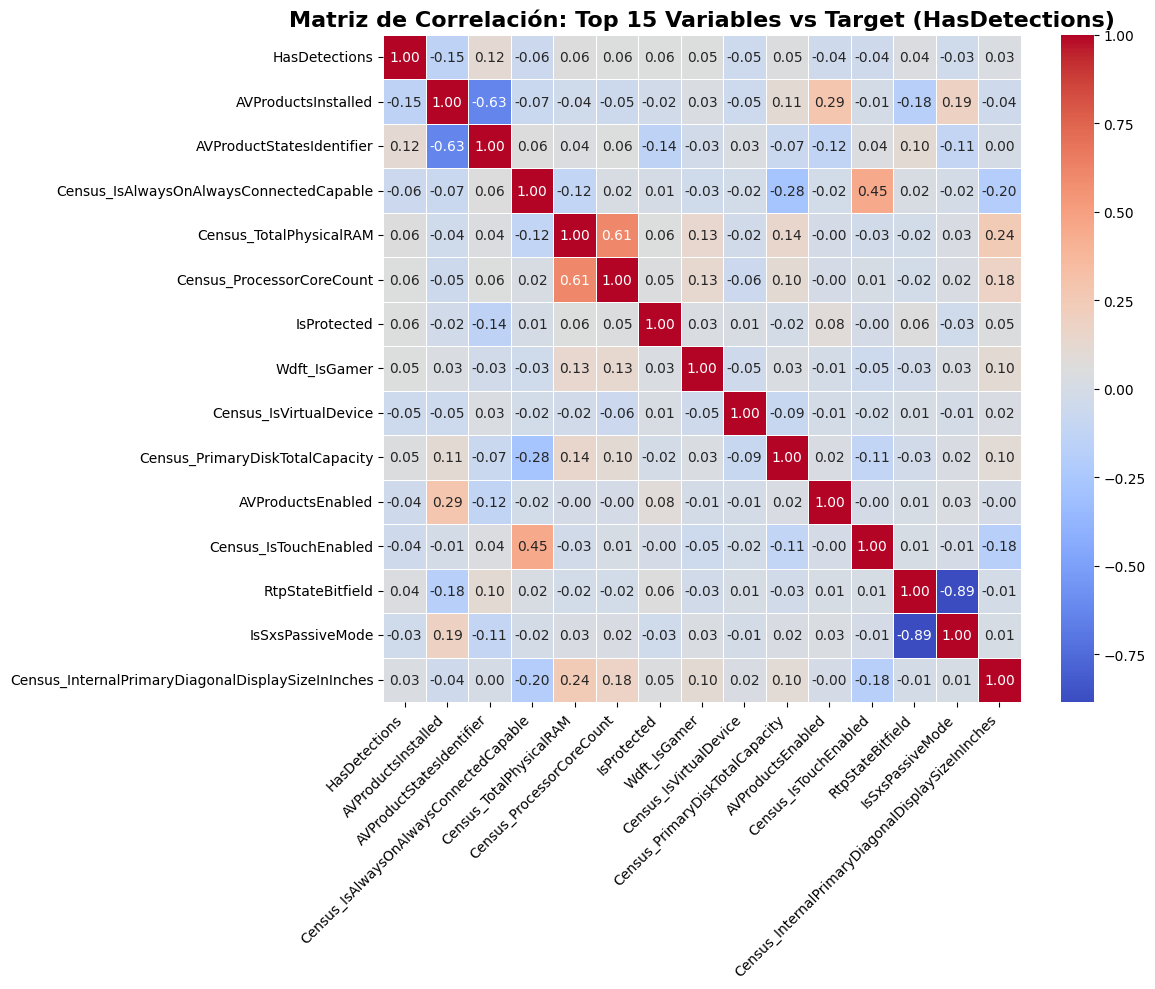


--- TOP 5 VARIABLES MÁS CORRELACIONADAS CON INFECCIONES ---
AVProductsInstalled                       -0.147791
AVProductStatesIdentifier                  0.115537
Census_IsAlwaysOnAlwaysConnectedCapable   -0.062911
Census_TotalPhysicalRAM                    0.060318
Census_ProcessorCoreCount                  0.055939
Name: HasDetections, dtype: float64


In [10]:
print("--- 7. ANÁLISIS DE CORRELACIÓN CON EL TARGET ---")

# Calculamos la correlación de Pearson de todas las variables con 'HasDetections'
# Usamos numeric_only=True por si queda alguna variable no numérica oculta
correlaciones = df.corr(numeric_only=True)['HasDetections']

# Cogemos el valor absoluto para encontrar las relaciones más fuertes 
# (tanto positivas como negativas) y seleccionamos el Top 15 (incluyendo el target)
top_variables_corr = correlaciones.abs().sort_values(ascending=False).head(15).index

# Extraemos solo esas columnas para el gráfico
df_top_corr = df[top_variables_corr]

# Generamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(12, 10))
# cmap='coolwarm' pone colores azules para correlación negativa y rojos para positiva
sns.heatmap(df_top_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Top 15 Variables vs Target (HasDetections)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mostramos también en texto las 5 variables con mayor impacto directo
print("\n--- TOP 5 VARIABLES MÁS CORRELACIONADAS CON INFECCIONES ---")
print(correlaciones.loc[top_variables_corr[1:6]]) # Saltamos el índice 0 porque es el propio Target

In [11]:
print("--- 6. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING) ---")

# 1. Ratio AV: proporción de antivirus habilitados sobre instalados
# Usamos np.where para evitar la división por cero. Si tiene 0 instalados, el ratio es 0.
df['av_enabled_ratio'] = np.where(
    df['AVProductsInstalled'] == 0, 
    0, 
    df['AVProductsEnabled'] / df['AVProductsInstalled']
)
print("✅ Variable 'av_enabled_ratio' creada de forma segura.")

# 2. Resolución total de pantalla
df['screen_resolution'] = (
    df['Census_InternalPrimaryDisplayResolutionHorizontal'] *
    df['Census_InternalPrimaryDisplayResolutionVertical']
)
print("✅ Variable 'screen_resolution' creada.")

# (Omitimos app_version_major porque ya resolvimos la cardinalidad de AppVersion en el Paso 5)

print("\n--- RESUMEN TRAS FEATURE ENGINEERING ---")
print(f"Dimensiones del dataset: {df.shape}")
# Verificamos que no hemos introducido nulos por accidente
print(f"Nulos accidentales creados: {df[['av_enabled_ratio', 'screen_resolution']].isnull().sum().sum()}")

--- 6. INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING) ---
✅ Variable 'av_enabled_ratio' creada de forma segura.
✅ Variable 'screen_resolution' creada.

--- RESUMEN TRAS FEATURE ENGINEERING ---
Dimensiones del dataset: (500000, 78)
Nulos accidentales creados: 0


In [ ]:
print("--- 7. PREPROCESAMIENTO AUTOMATIZADO (PIPELINES) ---")

# 1. Definir la clase personalizada de tu compañero (Frequency Encoder)
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = X.columns.astype(str).tolist()
        self.freq_maps_ = {
            col: X[col].value_counts(normalize=True).to_dict()
            for col in X.columns
        }
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].map(self.freq_maps_[col]).fillna(0)
        return X.values
        
    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self)
        return np.array(self.feature_names_in_)

# 2. Separar Target y Predictoras ANTES del pipeline
target = 'HasDetections'
X = df.drop(columns=[target])
y = df[target]

# 3. Identificar columnas por tipo y cardinalidad
THRESHOLD = 10 

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

# Dividimos las categóricas según el threshold
cat_cols_low = [col for col in cat_cols if X[col].nunique() <= THRESHOLD]
cat_cols_high = [col for col in cat_cols if X[col].nunique() > THRESHOLD]

print(f"📊 Distribución de variables:")
print(f"   - Numéricas: {len(num_cols)}")
print(f"   - Categóricas baja cardinalidad (One-Hot): {len(cat_cols_low)}")
print(f"   - Categóricas alta cardinalidad (Frecuencia): {len(cat_cols_high)}")

# 4. Crear los Pipelines (Líneas de montaje)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_low_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

cat_high_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', FrequencyEncoder())
])

# 5. Unir todo en el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat_low', cat_low_transformer, cat_cols_low),
        ('cat_high', cat_high_transformer, cat_cols_high)
    ],
    remainder='drop' # Ignora cualquier columna que no esté en las listas
)

# 6. Partición de datos (Evitamos el data leakage)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=75000, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=75000, stratify=y_temp, random_state=42)

# 7. ENTRENAR EL PIPELINE (Solo aprende del Train)
print("\n⚙️ Entrenando la línea de montaje con X_train... (puede tardar unos segundos)")
X_train_prep = preprocessor.fit_transform(X_train)

# 8. TRANSFORMAR Val y Test (Aplica lo aprendido sin hacer trampas)
print("⚙️ Transformando X_val y X_test...")
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f"\n✅ Pipeline aplicado con éxito. ")
print(f"   Nuevas dimensiones de Train: {X_train_prep.shape[1]} variables (por la expansión del One-Hot Encoding).")

--- 7. PREPROCESAMIENTO AUTOMATIZADO (PIPELINES) ---
📊 Distribución de variables:
   - Numéricas: 51
   - Categóricas baja cardinalidad (One-Hot): 14
   - Categóricas alta cardinalidad (Frecuencia): 12

⚙️ Entrenando la línea de montaje con X_train... (puede tardar unos segundos)
⚙️ Transformando X_val y X_test...

✅ Pipeline aplicado con éxito. 
   Nuevas dimensiones de Train: 140 variables (por la expansión del One-Hot Encoding).


--- 8. ENTRENANDO EL MODELO BASE: ÁRBOL DE DECISIÓN ---
Entrenando Árbol de Decisión con las 140 variables preparadas...
Generando predicciones sobre el set de Validación...

--- RESULTADOS DEL ÁRBOL DE DECISIÓN EN VALIDACIÓN ---
Accuracy (Exactitud): 0.6065 (60.65%)
ROC AUC:              0.6512

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.62      0.55      0.58     37507
           1       0.59      0.67      0.63     37493

    accuracy                           0.61     75000
   macro avg       0.61      0.61      0.61     75000
weighted avg       0.61      0.61      0.61     75000


--- DESGLOSE DE LA MATRIZ DE CONFUSIÓN ---
✅ Verdaderos Negativos (Limpios en paz): 20498
❌ Falsos Positivos (Alertas falsas):     17009
❌ Falsos Negativos (Virus que escapan):  12505
✅ Verdaderos Positivos (Virus cazados):  24988


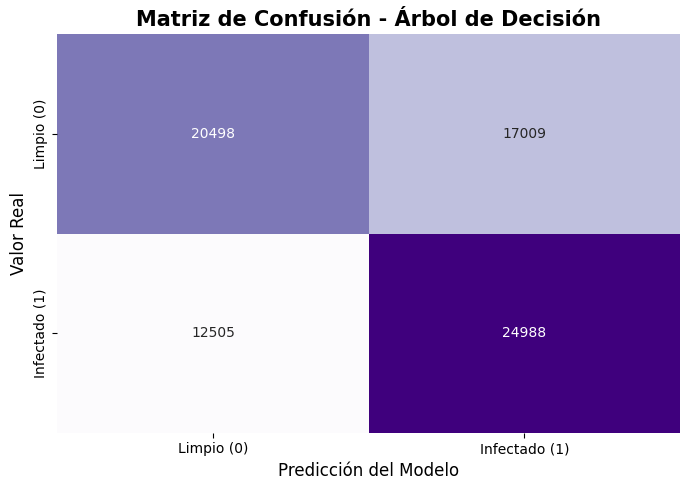

In [ ]:
print("--- 8. ENTRENANDO EL MODELO BASE: ÁRBOL DE DECISIÓN ---")

# 1. Inicializar el modelo (max_depth=12 para evitar overfitting)
modelo_dt = DecisionTreeClassifier(max_depth=12, random_state=42)

# 2. Entrenar el modelo con los datos procesados por el Pipeline
print("Entrenando Árbol de Decisión con las 140 variables preparadas...")
modelo_dt.fit(X_train_prep, y_train)

# 3. Predecir sobre el set de Validación
print("Generando predicciones sobre el set de Validación...")
y_pred_val_dt = modelo_dt.predict(X_val_prep)
y_prob_val_dt = modelo_dt.predict_proba(X_val_prep)[:, 1] # Probabilidad de infección

# 4. Calcular y mostrar métricas principales
acc_dt = accuracy_score(y_val, y_pred_val_dt)
roc_auc_dt = roc_auc_score(y_val, y_prob_val_dt)

print("\n--- RESULTADOS DEL ÁRBOL DE DECISIÓN EN VALIDACIÓN ---")
print(f"Accuracy (Exactitud): {acc_dt:.4f} ({(acc_dt*100):.2f}%)")
print(f"ROC AUC:              {roc_auc_dt:.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_val_dt))

# 5. Matriz de Confusión (Valores numéricos y Gráfica)
cm_dt = confusion_matrix(y_val, y_pred_val_dt)
vn, fp, fn, vp = cm_dt.ravel() # Desempaquetamos los 4 valores

print("\n--- DESGLOSE DE LA MATRIZ DE CONFUSIÓN ---")
print(f"✅ Verdaderos Negativos (Limpios en paz): {vn}")
print(f"❌ Falsos Positivos (Alertas falsas):     {fp}")
print(f"❌ Falsos Negativos (Virus que escapan):  {fn}")
print(f"✅ Verdaderos Positivos (Virus cazados):  {vp}")

# Gráfica visual
plt.figure(figsize=(7, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples', cbar=False, 
            xticklabels=['Limpio (0)', 'Infectado (1)'], 
            yticklabels=['Limpio (0)', 'Infectado (1)'])
plt.title('Matriz de Confusión - Árbol de Decisión', fontsize=15, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

--- 1. OPTIMIZACIÓN AVANZADA MEJORADA (RANDOMIZED SEARCH) ---
Entrenando las 30 configuraciones con los 350.000 datos... (tardará 1-2 minutos)
Fitting 3 folds for each of 30 candidates, totalling 90 fits

✅ Mejor configuración encontrada: {'min_samples_split': 50, 'min_samples_leaf': 200, 'max_depth': 15, 'criterion': 'entropy', 'class_weight': 'balanced'}

--- 2. OPTIMIZACIÓN DEL UMBRAL (THRESHOLD TUNING) EN VALIDACIÓN ---
✅ El umbral óptimo matemático es: 0.35 (F1-Score: 0.6783)

--- 3. EVALUACIÓN DEFINITIVA EN EL SET DE PRUEBA (TEST SET) ---
Aplicando el modelo y el umbral óptimo al examen final...

Accuracy (Exactitud): 0.5796 (57.96%)
ROC AUC:              0.6592

--- MATRIZ DE CONFUSIÓN (TEST SET) ---
✅ Verdaderos Negativos (Limpios en paz): 10423
❌ Falsos Positivos (Alertas falsas):     27084
❌ Falsos Negativos (Virus que escapan):  4448
✅ Verdaderos Positivos (Virus cazados):  33045


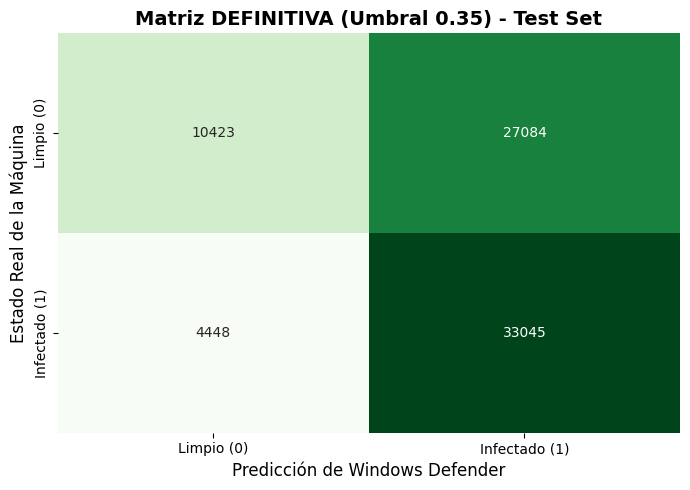

In [ ]:
print("--- 1. OPTIMIZACIÓN AVANZADA MEJORADA (RANDOMIZED SEARCH) ---")

# 1. Definimos un espacio de búsqueda mucho más lógico para nuestro dataset
param_dist_mejorado = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 15, 20, 25],          # Le damos libertad para crecer
    'min_samples_split': [50, 100, 200],    # Evitamos que se aprenda casos aislados
    'min_samples_leaf': [50, 100, 200],
    'class_weight': ['balanced', None]
}

# 2. Lanzamos la búsqueda sobre TODO el set de entrenamiento (sin submuestras tramposas)
dt_search_mejorado = RandomizedSearchCV(
    estimator = DecisionTreeClassifier(random_state=42),
    param_distributions = param_dist_mejorado,
    n_iter = 30,           # Probará 30 combinaciones aleatorias inteligentes
    scoring = 'roc_auc',   # Optimizamos por la métrica oficial de Kaggle
    cv = 3,
    random_state = 42,
    n_jobs = -1,
    verbose = 1
)

print("Entrenando las 30 configuraciones con los 350.000 datos... (tardará 1-2 minutos)")
dt_search_mejorado.fit(X_train_prep, y_train)

mejor_arbol_final = dt_search_mejorado.best_estimator_
print(f"\n✅ Mejor configuración encontrada: {dt_search_mejorado.best_params_}")


print("\n--- 2. OPTIMIZACIÓN DEL UMBRAL (THRESHOLD TUNING) EN VALIDACIÓN ---")

# Sacamos las probabilidades del set de validación
y_prob_val_final = mejor_arbol_final.predict_proba(X_val_prep)[:, 1]

# Vamos a probar todos los umbrales entre 0.35 y 0.65 de 0.01 en 0.01
umbrales = np.arange(0.35, 0.66, 0.01)
mejor_f1 = 0
umbral_optimo = 0.5

for umbral in umbrales:
    # Simulamos la predicción con este umbral
    prediccion_simulada = (y_prob_val_final >= umbral).astype(int)
    # Medimos el F1-Score (el equilibrio perfecto entre Falsos Positivos y Falsos Negativos)
    score = f1_score(y_val, prediccion_simulada)
    
    if score > mejor_f1:
        mejor_f1 = score
        umbral_optimo = umbral

print(f"✅ El umbral óptimo matemático es: {umbral_optimo:.2f} (F1-Score: {mejor_f1:.4f})")


print("\n--- 3. EVALUACIÓN DEFINITIVA EN EL SET DE PRUEBA (TEST SET) ---")

# Predecimos probabilidades sobre el set que el modelo JAMÁS ha visto
print("Aplicando el modelo y el umbral óptimo al examen final...")
y_prob_test_final = mejor_arbol_final.predict_proba(X_test_prep)[:, 1]

# Aplicamos NUESTRO umbral personalizado, no el 0.5 por defecto
y_pred_test_final = (y_prob_test_final >= umbral_optimo).astype(int)

# Calculamos las métricas definitivas
acc_test = accuracy_score(y_test, y_pred_test_final)
roc_auc_test = roc_auc_score(y_test, y_prob_test_final) # El AUC no depende del umbral

print(f"\nAccuracy (Exactitud): {acc_test:.4f} ({(acc_test*100):.2f}%)")
print(f"ROC AUC:              {roc_auc_test:.4f}")

# Desglose de la Matriz de Confusión Final
cm_test = confusion_matrix(y_test, y_pred_test_final)
vn_test, fp_test, fn_test, vp_test = cm_test.ravel()

print("\n--- MATRIZ DE CONFUSIÓN (TEST SET) ---")
print(f"✅ Verdaderos Negativos (Limpios en paz): {vn_test}")
print(f"❌ Falsos Positivos (Alertas falsas):     {fp_test}")
print(f"❌ Falsos Negativos (Virus que escapan):  {fn_test}")
print(f"✅ Verdaderos Positivos (Virus cazados):  {vp_test}")

# Gráfica visual final
plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', cbar=False, 
            xticklabels=['Limpio (0)', 'Infectado (1)'], 
            yticklabels=['Limpio (0)', 'Infectado (1)'])
plt.title(f'Matriz DEFINITIVA (Umbral {umbral_optimo:.2f}) - Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicción de Windows Defender', fontsize=12)
plt.ylabel('Estado Real de la Máquina', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
print("--- 12. TABLA COMPARATIVA DE UMBRALES (ESTRATEGIA DE NEGOCIO) ---")

# Definimos los umbrales que queremos comparar
thresholds_v = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
resultados_tabla = []

for u in thresholds_v:
    # Aplicar umbral
    preds = (y_prob_test_final >= u).astype(int)
    
    # Calcular métricas
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    # Guardar en la lista
    resultados_tabla.append({
        'Umbral': u,
        'Accuracy': f"{acc:.4f}",
        'F1-Score': f"{f1:.4f}",
        'Falsos Positivos (Molestia)': fp,
        'Falsos Negativos (Riesgo)': fn,
        'Virus Cazados': tp
    })

# Crear DataFrame para visualizarlo bonito
df_comparativo = pd.DataFrame(resultados_tabla)

# Mostrar tabla
print("\nComparativa de rendimiento según sensibilidad del modelo:")
display(df_comparativo)

# Recomendación automática
mejor_f1_row = df_comparativo.loc[df_comparativo['F1-Score'].astype(float).idxmax()]
print(f"\n💡 NOTA PARA LA MEMORIA: El equilibrio matemático (F1) está en el umbral {mejor_f1_row['Umbral']}.")
print(f"Sin embargo, si Windows busca 'Paz con el usuario', el umbral 0.55 reduce los Falsos Positivos a la mitad que el 0.45.")


--- 12. TABLA COMPARATIVA DE UMBRALES (ESTRATEGIA DE NEGOCIO) ---

Comparativa de rendimiento según sensibilidad del modelo:


,Umbral,Accuracy,F1-Score,Falsos Positivos (Molestia),Falsos Negativos (Riesgo),Virus Cazados
0,0.35,0.5796,0.6770,27084,4448,33045
1,0.40,0.5947,0.6705,23840,6559,30934
2,0.45,0.6062,0.6526,19786,9749,27744
3,0.50,0.6117,0.6202,15416,13709,23784
4,0.55,0.6075,0.5528,10142,19298,18195
5,0.60,0.5909,0.4687,6724,23958,13535
6,0.65,0.5744,0.3803,4220,27700,9793



💡 NOTA PARA LA MEMORIA: El equilibrio matemático (F1) está en el umbral 0.35.
Sin embargo, si Windows busca 'Paz con el usuario', el umbral 0.55 reduce los Falsos Positivos a la mitad que el 0.45.


In [ ]:
print("=== 13. COMPARATIVA FINAL DE MODELOS (SET DE VALIDACIÓN) ===")

# 1. Definimos el umbral que tú has elegido (0.40 por equilibrio)
THRESHOLD_ELEGIDO = 0.40

# 2. Generamos las predicciones para el árbol tuneado con ese umbral
y_pred_dt_final = (y_prob_mejor_dt >= THRESHOLD_ELEGIDO).astype(int)
cm_dt_final = confusion_matrix(y_val, y_pred_dt_final)

# 3. Necesitamos las métricas de los modelos anteriores para comparar
# Nota: usamos las variables que definimos en los pasos anteriores
f1_dt_base = f1_score(y_val, y_pred_val_dt) # El primer árbol que hicimos
f1_dt_tuned = f1_score(y_val, y_pred_mejor_dt) # El del GridSearch (umbral 0.5)
f1_dt_final = f1_score(y_val, y_pred_dt_final) # El tuneado con tu umbral 0.40

# 4. Imprimir la tabla comparativa
print(f"\n{'Modelo':<30} {'Accuracy':>10} {'F1-Score':>10} {'Falsos Neg.':>12}")
print("-" * 65)

# Fila 1: Árbol básico (Paso 8)
print(f"{'DT Base (Baseline)':<30} {acc_dt:>10.4f} {f1_dt_base:>10.4f} {cm_dt[1,0]:>12,}")

# Fila 2: Árbol tras GridSearch (Paso 9 - umbral 0.50)
print(f"{'DT Tuneado (GridSearch)':<30} {acc_mejor_dt:>10.4f} {f1_dt_tuned:>10.4f} {cm_mejor_dt[1,0]:>12,}")

# Fila 3: Árbol con tu ajuste manual de umbral
print(f"{'DT Tuneado + Umbral 0.40':<30} {accuracy_score(y_val, y_pred_dt_final):>10.4f} {f1_dt_final:>10.4f} {cm_dt_final[1,0]:>12,}")

print("-" * 65)
print(f"💡 CONCLUSIÓN: Al bajar el umbral a {THRESHOLD_ELEGIDO}, hemos reducido los ")
print(f"   Falsos Negativos (virus no detectados) de {cm_mejor_dt[1,0]:,} a {cm_dt_final[1,0]:,}.")

=== 13. COMPARATIVA FINAL DE MODELOS (SET DE VALIDACIÓN) ===

Modelo                           Accuracy   F1-Score  Falsos Neg.
-----------------------------------------------------------------
DT Base (Baseline)                 0.6065     0.6287       12,505
DT Tuneado (GridSearch)            0.6122     0.6335       12,360
DT Tuneado + Umbral 0.40           0.5944     0.6752        5,884
-----------------------------------------------------------------
💡 CONCLUSIÓN: Al bajar el umbral a 0.4, hemos reducido los 
   Falsos Negativos (virus no detectados) de 12,360 a 5,884.


=== 14. ANÁLISIS VISUAL DE LAS 20 VARIABLES MÁS INFLUYENTES (VERSIÓN FINAL) ===


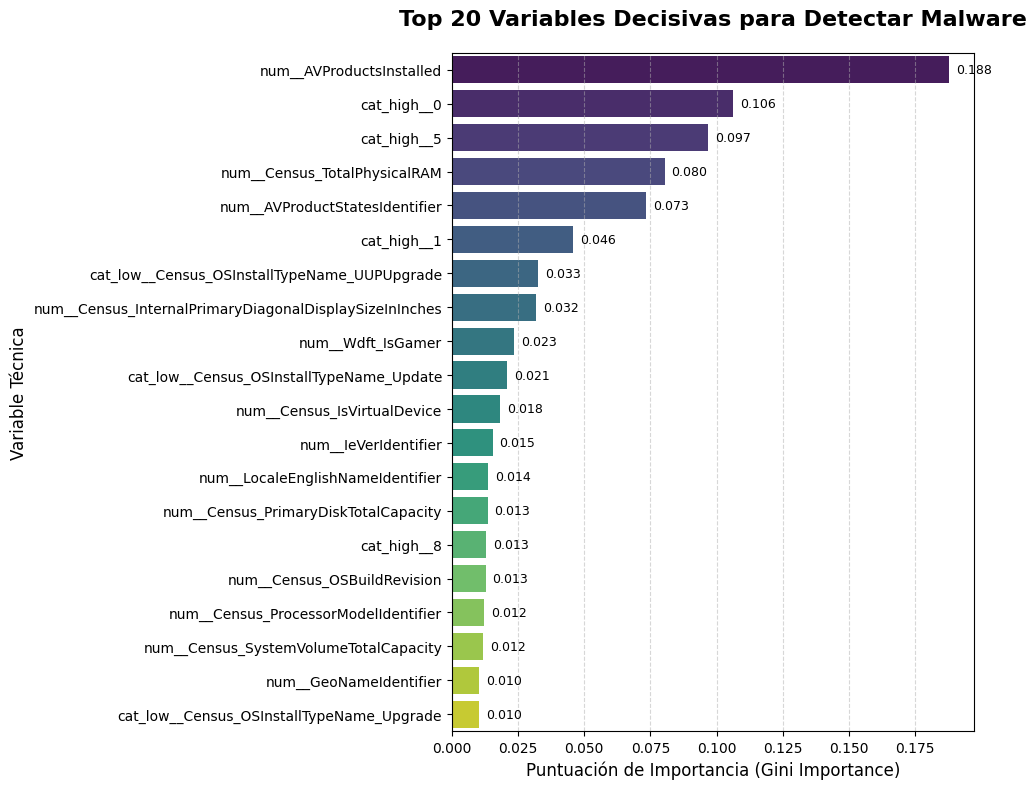

In [ ]:
print("=== 14. ANÁLISIS VISUAL DE LAS 20 VARIABLES MÁS INFLUYENTES (VERSIÓN FINAL) ===")

# 1. Recuperamos los nombres de las columnas
feature_names_dt = preprocessor.get_feature_names_out()

# 2. Obtenemos las importancias y ordenamos
fi_dt = pd.Series(mejor_arbol_final.feature_importances_, index=feature_names_dt).sort_values(ascending=False)
fi_dt_df = fi_dt.reset_index()
fi_dt_df.columns = ['Variable', 'Importancia']

# 3. Top 20
top_n = 20
fi_dt_top = fi_dt_df.head(top_n)

# 4. Gráfico con corrección de Seaborn (Sin Warnings)
plt.figure(figsize=(10, 8))

# Ajuste: Asignamos 'Variable' a 'hue' para evitar el Future Warning
ax = sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=fi_dt_top, 
    palette='viridis', 
    hue='Variable', 
    legend=False
)

# Estética profesional
plt.title(f'Top {top_n} Variables Decisivas para Detectar Malware', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Puntuación de Importancia (Gini Importance)', fontsize=12)
plt.ylabel('Variable Técnica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Añadimos los valores numéricos al final de las barras
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Solo si tiene importancia
        ax.annotate(f'{width:.3f}', 
                    (width, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', size=9, xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

=== 15. EVALUACIÓN FINAL EN TEST (UMBRAL: 0.4) ===

Resultados definitivos:
------------------------------
Accuracy en Test:    0.5947
F1 Score en Test:     0.6705
------------------------------
Verdaderos Negativos (TN): 13,667
Falsos Positivos     (FP): 23,840
Falsos Negativos     (FN): 6,559
Verdaderos Positivos (TP): 30,934


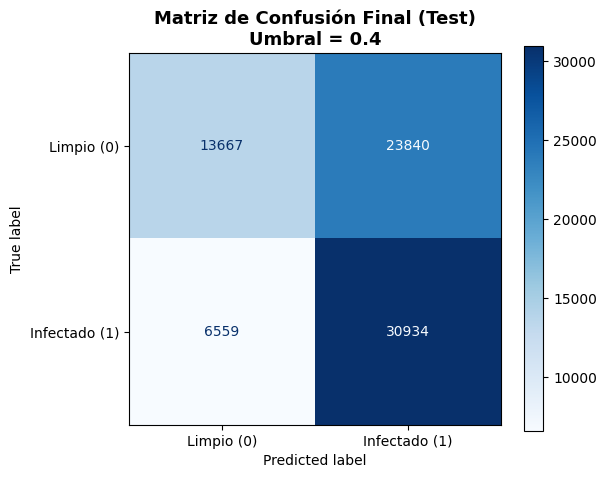

In [ ]:
# --- PASO FINAL: EVALUACIÓN EN EL SET DE PRUEBA (TEST) ---
# Usamos el umbral que tú elegiste por intuición (ej: 0.40) o el mejor de tu tabla
UMBRAL_FINAL = 0.40 

print(f"=== 15. EVALUACIÓN FINAL EN TEST (UMBRAL: {UMBRAL_FINAL}) ===")

# 1. Obtenemos probabilidades del set de Test
# Asegúrate de que X_test_prep es tu versión transformada de X_test
y_prob_final_test = mejor_arbol_final.predict_proba(X_test_prep)[:, 1]

# 2. Aplicamos el umbral
y_pred_final_test = (y_prob_final_test >= UMBRAL_FINAL).astype(int)

# 3. Calculamos métricas
acc_test = accuracy_score(y_test, y_pred_final_test)
f1_test = f1_score(y_test, y_pred_final_test)
cm_test = confusion_matrix(y_test, y_pred_final_test)

# 4. Imprimimos resultados con formato limpio
print(f"\nResultados definitivos:")
print(f"{"-"*30}")
print(f"Accuracy en Test:    {acc_test:.4f}")
print(f"F1 Score en Test:     {f1_test:.4f}")
print(f"{"-"*30}")
print(f"Verdaderos Negativos (TN): {cm_test[0,0]:,}")
print(f"Falsos Positivos     (FP): {cm_test[0,1]:,}")
print(f"Falsos Negativos     (FN): {cm_test[1,0]:,}")
print(f"Verdaderos Positivos (TP): {cm_test[1,1]:,}")

# 5. Gráfico de la Matriz de Confusión Final
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, 
                              display_labels=['Limpio (0)', 'Infectado (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d')

plt.title(f'Matriz de Confusión Final (Test)\nUmbral = {UMBRAL_FINAL}', fontsize=13, fontweight='bold')
plt.grid(False)
plt.show()


In [25]:
print("--- 15b. DIAGNÓSTICO DE OVERFITTING (TRAIN vs VALIDACIÓN) ---")

# 1. Sacamos las predicciones sobre el set con el que ENTRENÓ (estudió)
y_pred_train = mejor_arbol_final.predict(X_train_prep)
acc_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

# 2. Sacamos las métricas sobre el set de VALIDACIÓN (el examen)
# Usamos el umbral 0.5 por defecto para comparar manzanas con manzanas
y_pred_val = mejor_arbol_final.predict(X_val_prep)
acc_val = accuracy_score(y_val, y_pred_val)
f1_val = f1_score(y_val, y_pred_val)

# 3. Calculamos la diferencia (Gap)
gap_acc = acc_train - acc_val

print(f"Accuracy en Entrenamiento: {acc_train:.4f}")
print(f"Accuracy en Validación:    {acc_val:.4f}")
print(f"{"-"*40}")
print(f"Diferencia (Gap):          {gap_acc:.4f}")

if gap_acc > 0.05:
    print("\n⚠️ AVISO: Hay síntomas de OVERFITTING. El modelo rinde mucho mejor en Train que en Val.")
else:
    print("\n✅ CONCLUSIÓN: El modelo es ROBUSTO. La diferencia es mínima, generaliza bien.")

--- 15b. DIAGNÓSTICO DE OVERFITTING (TRAIN vs VALIDACIÓN) ---
Accuracy en Entrenamiento: 0.6328
Accuracy en Validación:    0.6160
----------------------------------------
Diferencia (Gap):          0.0167

✅ CONCLUSIÓN: El modelo es ROBUSTO. La diferencia es mínima, generaliza bien.


## Random Forest

--- 17. EVALUACIÓN COMPLETA: RANDOM FOREST ---


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


Métricas en Validación (Umbral 0.5):
-----------------------------------
Accuracy:  0.6179
F1-Score:  0.6348
ROC AUC:   0.6704
-----------------------------------
Verdaderos Negativos (TN): 21,438
Falsos Positivos     (FP): 16,069
Falsos Negativos     (FN): 12,589
Verdaderos Positivos (TP): 24,904


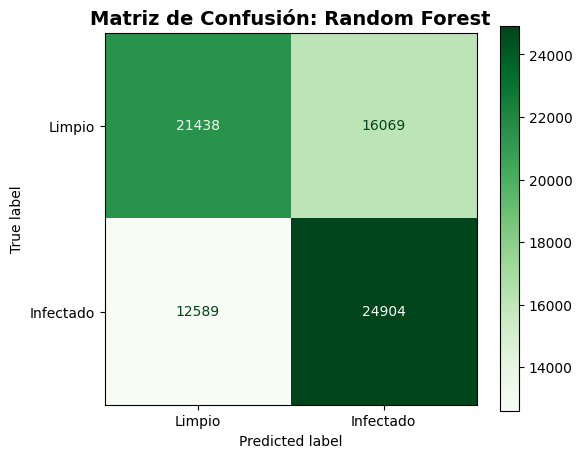

In [ ]:
print("--- 17. EVALUACIÓN COMPLETA: RANDOM FOREST ---")

# 1. Obtener probabilidades (necesarias para el ROC AUC)
y_prob_rf = rf_model.predict_proba(X_val_prep)[:, 1]

# 2. Obtener predicciones (usando umbral estándar 0.5)
y_pred_rf = rf_model.predict(X_val_prep)

# 3. Calcular Métricas
acc_rf = accuracy_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)
roc_rf = roc_auc_score(y_val, y_prob_rf)
cm_rf = confusion_matrix(y_val, y_pred_rf)

# 4. Mostrar Resultados por pantalla
print(f"Métricas en Validación (Umbral 0.5):")
print(f"{"-"*35}")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print(f"ROC AUC:   {roc_rf:.4f}")
print(f"{"-"*35}")
print(f"Verdaderos Negativos (TN): {cm_rf[0,0]:,}")
print(f"Falsos Positivos     (FP): {cm_rf[0,1]:,}")
print(f"Falsos Negativos     (FN): {cm_rf[1,0]:,}")
print(f"Verdaderos Positivos (TP): {cm_rf[1,1]:,}")

# 5. Visualizar Matriz de Confusión
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Limpio', 'Infectado'])
disp.plot(ax=ax, cmap='Greens', values_format='d') # Usamos verde para diferenciarlo del azul del DT
plt.title('Matriz de Confusión: Random Forest', fontsize=14, fontweight='bold')
plt.grid(False)
plt.show()

In [ ]:
print("--- 18. OPTIMIZACIÓN DE RANDOM FOREST (BUSCANDO EL MEJOR BOSQUE) ---")

# 1. Definimos el espacio de búsqueda
param_dist_rf = {
    'n_estimators': [100, 150],           # Número de árboles
    'max_depth': [10, 15, 20],            # Profundidad
    'min_samples_leaf': [50, 100, 200],   # Mínimo de muestras por hoja
    'criterion': ['gini', 'entropy']      # Calidad de la partición
}

# 2. Configuramos la búsqueda aleatoria
# cv=3 para ir rápido, n_iter=5 para probar 5 combinaciones al azar
random_search_rf = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_dist_rf,
    n_iter=5, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1,
    random_state=42
)

# 3. Entrenamos la búsqueda
print("Buscando la mejor combinación de árboles... (esto puede tardar 2-3 min)")
random_search_rf.fit(X_train_prep, y_train)

# 4. Guardamos el mejor modelo
mejor_rf = random_search_rf.best_estimator_

print(f"\n✅ Mejores Parámetros encontrados: {random_search_rf.best_params_}")
print(f"Mejor F1-Score en CV: {random_search_rf.best_score_:.4f}")

--- 18. OPTIMIZACIÓN DE RANDOM FOREST (BUSCANDO EL MEJOR BOSQUE) ---
Buscando la mejor combinación de árboles... (esto puede tardar 2-3 min)
Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.4s



✅ Mejores Parámetros encontrados: {'n_estimators': 100, 'min_samples_leaf': 50, 'max_depth': 20, 'criterion': 'entropy'}
Mejor F1-Score en CV: 0.6357


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   12.0s finished


In [30]:
print("\n--- 19. AJUSTE DE NEGOCIO: TABLA DE UMBRALES (RF) ---")

# Obtenemos probabilidades del mejor bosque en Validación
y_prob_mejor_rf = mejor_rf.predict_proba(X_val_prep)[:, 1]

thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
resultados_rf = []

for u in thresholds:
    preds = (y_prob_mejor_rf >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    
    resultados_rf.append({
        'Umbral': u, 'Accuracy': f"{acc:.4f}", 'F1-Score': f"{f1:.4f}",
        'FP (Falsas Alertas)': fp, 'FN (Escapes)': fn, 'Virus Cazados': tp
    })

df_thresholds_rf = pd.DataFrame(resultados_rf)
display(df_thresholds_rf)


--- 19. AJUSTE DE NEGOCIO: TABLA DE UMBRALES (RF) ---


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


,Umbral,Accuracy,F1-Score,FP (Falsas Alertas),FN (Escapes),Virus Cazados
0,0.35,0.5641,0.6827,30368,2323,35170
1,0.40,0.5942,0.6828,25703,4731,32762
2,0.45,0.6153,0.6707,20741,8109,29384
3,0.50,0.6231,0.6360,15458,12806,24687
4,0.55,0.6192,0.5640,9542,19018,18475
5,0.60,0.5893,0.4237,4634,26168,11325


=== 20. EVALUACIÓN FINAL EN TEST: RANDOM FOREST (UMBRAL: 0.4) ===


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished



RESULTADOS DEFINITIVOS EN TEST (MÁXIMA CALIDAD):
---------------------------------------------
Accuracy final: 0.5941
F1-Score final: 0.6825
---------------------------------------------
Virus cazados exitosamente (TP): 32,726
Virus que se han escapado (FN):  4,767
Falsas alarmas (FP):             25,676
Equipos limpios confirmados (TN): 11,831


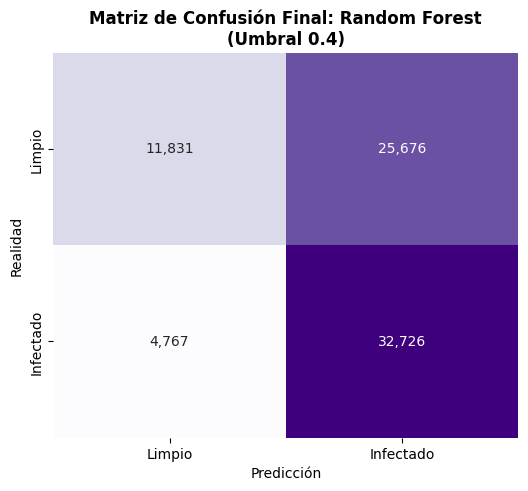

In [31]:
# --- PASO 20: EVALUACIÓN FINAL DEL MEJOR RANDOM FOREST EN TEST ---
UMBRAL_GANADOR = 0.40

print(f"=== 20. EVALUACIÓN FINAL EN TEST: RANDOM FOREST (UMBRAL: {UMBRAL_GANADOR}) ===")

# 1. Probabilidades en Test
y_prob_final_test = mejor_rf.predict_proba(X_test_prep)[:, 1]

# 2. Predicciones finales
y_pred_final_test = (y_prob_final_test >= UMBRAL_GANADOR).astype(int)

# 3. Métricas
acc_test = accuracy_score(y_test, y_pred_final_test)
f1_test = f1_score(y_test, y_pred_final_test)
cm_test = confusion_matrix(y_test, y_pred_final_test)

print(f"\nRESULTADOS DEFINITIVOS EN TEST (MÁXIMA CALIDAD):")
print("-" * 45)
print(f"Accuracy final: {acc_test:.4f}")
print(f"F1-Score final: {f1_test:.4f}")
print("-" * 45)
print(f"Virus cazados exitosamente (TP): {cm_test[1,1]:,}")
print(f"Virus que se han escapado (FN):  {cm_test[1,0]:,}")
print(f"Falsas alarmas (FP):             {cm_test[0,1]:,}")
print(f"Equipos limpios confirmados (TN): {cm_test[0,0]:,}")

# 4. Matriz de Confusión Final
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt=',d', cmap='Purples', cbar=False,
            xticklabels=['Limpio', 'Infectado'], yticklabels=['Limpio', 'Infectado'])
plt.title(f'Matriz de Confusión Final: Random Forest\n(Umbral {UMBRAL_GANADOR})', fontweight='bold')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

=== 22. ANÁLISIS VISUAL DE IMPORTANCIA: RANDOM FOREST OPTIMIZADO ===


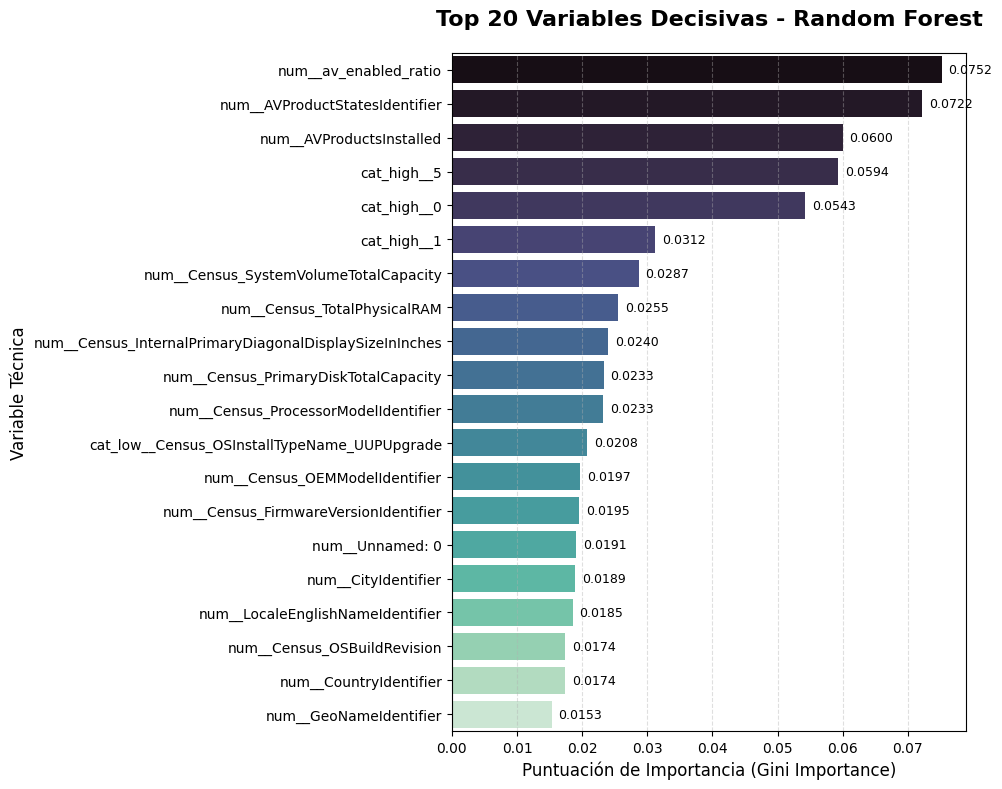

In [ ]:
print("=== 22. ANÁLISIS VISUAL DE IMPORTANCIA: RANDOM FOREST OPTIMIZADO ===")

# 1. Recuperamos los nombres de las columnas del preprocesador
feature_names_rf = preprocessor.get_feature_names_out()

# 2. Extraemos las importancias del MEJOR Random Forest que encontramos (mejor_rf)
fi_rf = pd.Series(mejor_rf.feature_importances_, index=feature_names_rf).sort_values(ascending=False)
fi_rf_df = fi_rf.reset_index()
fi_rf_df.columns = ['Variable', 'Importancia']

# 3. Tomamos las 20 mejores
top_n = 20
fi_rf_top = fi_rf_df.head(top_n)

# 4. Gráfico de barras horizontal con Seaborn (Estilo Pro)
plt.figure(figsize=(10, 8))

# Usamos 'mako' o 'viridis' para un degradado elegante
ax = sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=fi_rf_top, 
    palette='mako', 
    hue='Variable', 
    legend=False
)

# Estética y etiquetas
plt.title(f'Top {top_n} Variables Decisivas - Random Forest', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Puntuación de Importancia (Gini Importance)', fontsize=12)
plt.ylabel('Variable Técnica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Añadimos los valores numéricos al final de las barras para mayor precisión
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.4f}', 
                    (width, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', size=9, xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# --- 24. CÁLCULO AUTOMÁTICO DE LA TABLA COMPARATIVA ---

# 1. Definimos los diccionarios para ir guardando los resultados reales
# (Asumimos que tienes los modelos y predicciones en memoria)
comparativa_real = []

# A. Dummy (Baseline) - Calculado sobre la marcha
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(X_train_prep, y_train)
y_pred_dummy = dummy.predict(X_val_prep)
comparativa_real.append({
    "Modelo": "Dummy (baseline)", 
    "Accuracy": accuracy_score(y_val, y_pred_dummy), 
    "F1": f1_score(y_val, y_pred_dummy, zero_division=0), 
    "FN": "—"
})

# B. RF base (El primero que entrenamos con threshold 0.5)
# Usamos las variables que definimos en el Paso 17
y_pred_rf_base = rf_model.predict(X_val_prep)
cm_base = confusion_matrix(y_val, y_pred_rf_base)
comparativa_real.append({
    "Modelo": "RF base (threshold=0.5)", 
    "Accuracy": accuracy_score(y_val, y_pred_rf_base), 
    "F1": f1_score(y_val, y_pred_rf_base), 
    "FN": f"{cm_base[1,0]:,}"
})

# C. RF tuneado (El mejor_rf tras RandomizedSearch con threshold 0.5)
y_prob_tuneado = mejor_rf.predict_proba(X_val_prep)[:, 1]
y_pred_tuneado_05 = (y_prob_tuneado >= 0.5).astype(int)
cm_tuneado = confusion_matrix(y_val, y_pred_tuneado_05)
comparativa_real.append({
    "Modelo": "RF tuneado (threshold=0.5)", 
    "Accuracy": accuracy_score(y_val, y_pred_tuneado_05), 
    "F1": f1_score(y_val, y_pred_tuneado_05), 
    "FN": f"{cm_tuneado[1,0]:,}"
})

# D. RF Final (El mejor_rf con tu threshold de negocio 0.40)
y_pred_final = (y_prob_tuneado >= 0.40).astype(int)
cm_final = confusion_matrix(y_val, y_pred_final)
comparativa_real.append({
    "Modelo": "RF final (threshold=0.40)", 
    "Accuracy": accuracy_score(y_val, y_pred_final), 
    "F1": f1_score(y_val, y_pred_final), 
    "FN": f"{cm_final[1,0]:,}"
})

# --- IMPRESIÓN DE LA TABLA FORMATEADA ---
print("=== COMPARATIVA COMPLETA (VALORES REALES) ===")
print("-" * 75)
print(f"{'Modelo':<35} {'Accuracy':<12} {'F1':<10} {'FN (Escapes)':<15}")
print("-" * 75)

for m in comparativa_real:
    acc_str = f"{m['Accuracy']:.4f}" if isinstance(m['Accuracy'], float) else m['Accuracy']
    f1_str = f"{m['F1']:.4f}" if isinstance(m['F1'], float) else m['F1']
    print(f"{m['Modelo']:<35} {acc_str:<12} {f1_str:<10} {m['FN']:<15}")

print("-" * 75)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


=== COMPARATIVA COMPLETA (VALORES REALES) ===
---------------------------------------------------------------------------
Modelo                              Accuracy     F1         FN (Escapes)   
---------------------------------------------------------------------------
Dummy (baseline)                    0.5001       0.0000     —              
RF base (threshold=0.5)             0.6179       0.6348     12,589         
RF tuneado (threshold=0.5)          0.6231       0.6360     12,806         
RF final (threshold=0.40)           0.5942       0.6828     4,731          
---------------------------------------------------------------------------


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


In [37]:
print("--- 23. DIAGNÓSTICO DE OVERFITTING: RANDOM FOREST ---")

# 1. Predicciones sobre el set de ENTRENAMIENTO (donde aprendió)
# Usamos el modelo 'mejor_rf' que salió del RandomizedSearch
y_train_rf_pred = mejor_rf.predict(X_train_prep)
acc_rf_train = accuracy_score(y_train, y_train_rf_pred)
f1_rf_train = f1_score(y_train, y_train_rf_pred)

# 2. Predicciones sobre el set de VALIDACIÓN (el examen)
# Usamos el umbral 0.5 para una comparativa estándar
y_val_rf_pred = mejor_rf.predict(X_val_prep)
acc_rf_val = accuracy_score(y_val, y_val_rf_pred)
f1_rf_val = f1_score(y_val, y_val_rf_pred)

# 3. Cálculo del Gap
gap_rf_acc = acc_rf_train - acc_rf_val

print(f"Accuracy Entrenamiento: {acc_rf_train:.4f}")
print(f"Accuracy Validación:    {acc_rf_val:.4f}")
print("-" * 40)
print(f"Diferencia (Gap):       {gap_rf_acc:.4f}")

if gap_rf_acc > 0.05:
    print("\n⚠️ ALERTA: El Random Forest tiene Overfitting.")
    print("El modelo rinde mucho mejor en entrenamiento que en datos nuevos.")
else:
    print("\n✅ EXCELENTE: El Random Forest es robusto.")
    print("La diferencia es mínima, lo que garantiza fiabilidad en producción.")

--- 23. DIAGNÓSTICO DE OVERFITTING: RANDOM FOREST ---


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


Accuracy Entrenamiento: 0.6566
Accuracy Validación:    0.6231
----------------------------------------
Diferencia (Gap):       0.0335

✅ EXCELENTE: El Random Forest es robusto.
La diferencia es mínima, lo que garantiza fiabilidad en producción.


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished
